In [88]:
from autoenkoop import *
import torch
import numpy as np
import pandas as pd
import os
from matplotlib.colors import Normalize
from tqdm import tqdm

In [89]:
datafile = np.load(os.path.join("..", "data", "T1492_x1151_y1_z127_c2.npz"))
data = datafile['timeseries']
tempmean = np.mean(data, axis=0)
data_centered = data - tempmean
train_data = data_centered[:int(data_centered.shape[0]*0.7)]

(vx_min, vx_max), (vz_min, vz_max) = get_min_max(data_centered)
norm_x = Normalize(vmin=vx_min, vmax=vx_max)
norm_z = Normalize(vmin=vz_min, vmax=vz_max)

In [161]:
results_path = os.path.join("..", "results")
#run_path = os.path.join(results_path, "koopman_autoencoder_classic", "lambda_001")
run_path = os.path.join(results_path, "koopman_autoencoder_directK_linerror_tracking", "L32_e300_lr0.0002_K0Dec_equalW")
#run_path = os.path.join(results_path, "koopman_autoencoder_multistep_exponential", "L128_a20_e300_lr0.0003_st5_norm")

In [162]:
LATENT_DIMENSION = 32
DEVICE = "cpu"#"cuda" if torch.cuda.is_available() else "cpu"
kae_model = ConvAutoencoderZeroDecoder(latent_dim=LATENT_DIMENSION).to(DEVICE)

In [163]:
kae_model.load_state_dict(torch.load(os.path.join(run_path, "model.pt"), map_location=DEVICE))
kae_model.eval()

ConvAutoencoderZeroDecoder(
  (encoder): Sequential(
    (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): GELU(approximate='none')
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): GELU(approximate='none')
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): GELU(approximate='none')
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=73728, out_features=1024, bias=True)
    (14): GELU(approximate='none')
    (15)

In [164]:
permuted_data = torch.tensor(train_data, dtype=torch.float32).permute(0,3,1,2)

In [165]:
lifted_states = []

with torch.no_grad():
    for x_t in permuted_data:
        z_t = kae_model.encoder(x_t.unsqueeze(0))
        lifted_states.append(z_t.squeeze(0).numpy())

In [166]:
lifted_states = np.array(lifted_states)

In [182]:
import pydmd
dmd_exact = pydmd.DMD(-1, forward_backward=True)

In [183]:
dmd_exact.fit(lifted_states.T)

In [184]:
eigenvaluesB = dmd_exact.eigs
eigenvectorsB = dmd_exact.modes
energiesB = eigenvalue_energies(kae_model, eigenvectorsB, DEVICE)

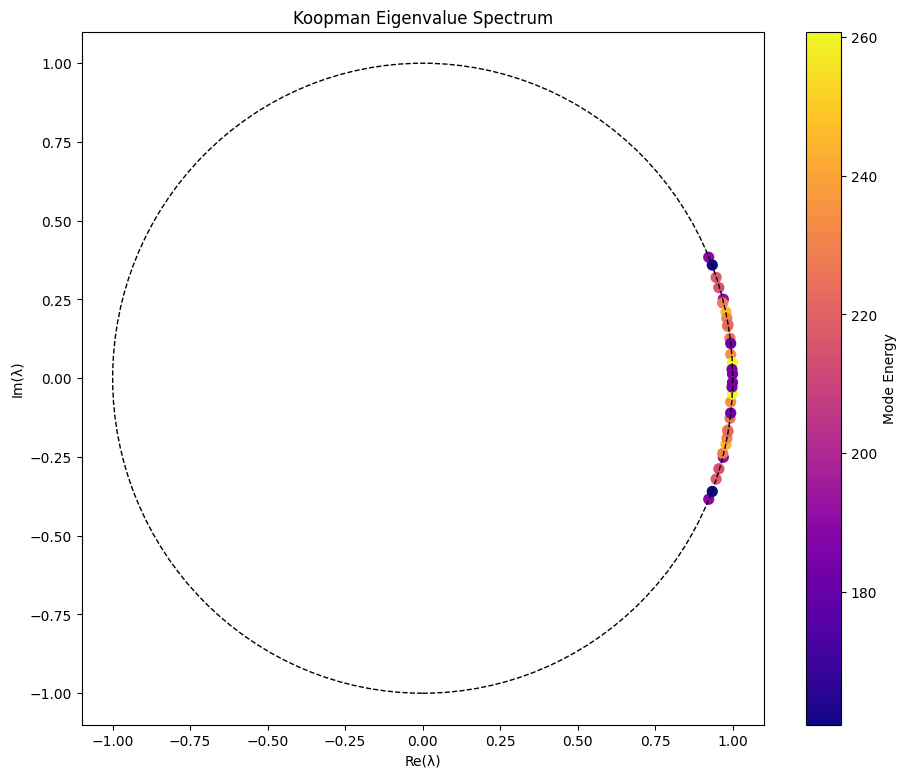

In [185]:
plot_eigenvalue_spectrum(eigenvaluesB, eigenvectorsB, energiesB)

In [41]:
X = lifted_states[:-1,:].T
X_shift = lifted_states[1:,:].T

In [42]:
A = X_shift @ np.linalg.pinv(X)

In [43]:
eigvalsA, eigvecsA = get_sorted_eigen(A)

In [44]:
energiesA = eigenvalue_energies(kae_model, eigvecsA, DEVICE)

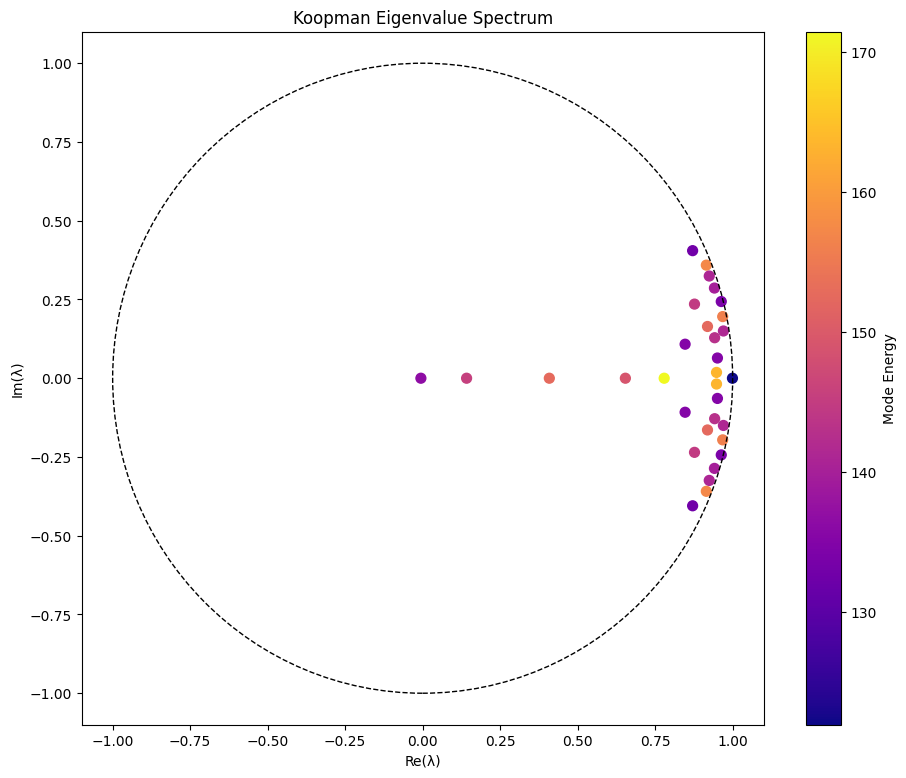

In [45]:
plot_eigenvalue_spectrum(eigvalsA, eigvecsA, energiesA)

In [ ]:
with torch.no_grad():
    K = kae_model.linear_dynamics.weight.detach().cpu().numpy()
eigvals, eigvecs = get_sorted_eigen(K)

In [ ]:
energies = eigenvalue_energies(kae_model, eigvecs, DEVICE)

In [ ]:
plot_eigenvalue_spectrum(eigvals, eigvecs, energies)

In [189]:
steady_tolerance = 0.01

stable_values, stable_vectors, stable_energies = get_stable_modes(eigenvaluesB, eigenvectorsB, energiesB, steady_tolerance, False)

32 stable mode explain: 100.00% of the energy


In [172]:
def prediction_mse(data, start_index, prediction_length, eigenvalues, eigenvectors, model):
    x0 = torch.tensor(data[start_index]).permute(2,0,1).unsqueeze(0)
    stable_predicted_trajectory = predict_trajectory_reduced(x0, model, eigenvalues, eigenvectors, prediction_length)
    stable_predicted_trajectory = np.array(stable_predicted_trajectory).reshape(prediction_length, -1)
    true_trajectory = np.permute_dims(data[start_index:start_index+prediction_length], (0,3,1,2)).reshape(prediction_length, -1)
    mse = np.mean((stable_predicted_trajectory - true_trajectory)**2, 1)
    return mse

In [173]:
window = 50

mse_list = []
for i in tqdm(range(len(data_centered)-window-1000)):
    mse_list.append(prediction_mse(data_centered, i, window, stable_values, stable_vectors, kae_model))
mse_array32_equalW300 = np.array(mse_list)

100%|██████████| 443/443 [10:32<00:00,  1.43s/it]


In [174]:
#global_mse27_mean = np.mean(mse_array, 0)
#global_mse9_mean = np.mean(mse_array9, 0)
#global_mse128_mean = np.mean(mse_array128, 0)
global_mse_array32_equalW300 = np.mean(mse_array32_equalW300, 0)
#global_mse_array13 = np.mean(mse_array112_new, 0)
#global_mse_std = np.std(mse_array, 0)

In [175]:
global_mse_array32_equalW300

array([0.04121583, 0.0414977 , 0.04245444, 0.04388799, 0.0456723 ,
       0.04770241, 0.04988745, 0.0522192 , 0.05470996, 0.05734075,
       0.06006128, 0.06284229, 0.06569438, 0.06858505, 0.07149926,
       0.07439422, 0.07720034, 0.0798436 , 0.08237981, 0.08492046,
       0.08749714, 0.09015304, 0.09290727, 0.09570184, 0.09848725,
       0.10124721, 0.10396818, 0.10664497, 0.10924314, 0.11175266,
       0.11412407, 0.1163132 , 0.11840886, 0.12042819, 0.12239403,
       0.12432351, 0.12616023, 0.12783313, 0.12937598, 0.13072407,
       0.13183647, 0.13272074, 0.13344567, 0.13416564, 0.13493416,
       0.13576932, 0.13666795, 0.13764079, 0.1386884 , 0.13981181],
      dtype=float32)

In [148]:
global_mse_array32_equalW

array([0.0652655 , 0.06976366, 0.07737404, 0.08290578, 0.08649891,
       0.08885437, 0.09048996, 0.0917496 , 0.09283773, 0.09393781,
       0.09518049, 0.09651769, 0.09792244, 0.09949932, 0.10133401,
       0.10336099, 0.10547344, 0.10760421, 0.10973321, 0.11180695,
       0.11379772, 0.11567651, 0.1174042 , 0.11897697, 0.1203697 ,
       0.1216193 , 0.12283802, 0.12414143, 0.12558554, 0.12714097,
       0.12870012, 0.13021603, 0.13169065, 0.13309549, 0.13439251,
       0.13558206, 0.13667385, 0.137742  , 0.13889173, 0.14014983,
       0.14150494, 0.14299184, 0.14460681, 0.1462423 , 0.14776592,
       0.14910921, 0.15027574, 0.15134992, 0.152434  , 0.15354691],
      dtype=float32)

In [125]:
global_mse_array32_decay

array([0.05381224, 0.05375469, 0.05464794, 0.05586142, 0.05783371,
       0.05994871, 0.06230351, 0.06477046, 0.06709483, 0.0691425 ,
       0.07104626, 0.07295968, 0.07496896, 0.07711747, 0.07942555,
       0.08190062, 0.08447162, 0.08707478, 0.08967803, 0.09225652,
       0.09476986, 0.09717985, 0.09945949, 0.10162543, 0.10366618,
       0.10551985, 0.10714595, 0.10862876, 0.11008548, 0.11157512,
       0.11315776, 0.11483011, 0.11655792, 0.11829488, 0.12006467,
       0.1219032 , 0.12374552, 0.12547097, 0.12704882, 0.12851143,
       0.12995736, 0.13143311, 0.13287461, 0.13423996, 0.13553149,
       0.13676009, 0.13797635, 0.13915548, 0.14026359, 0.1412951 ],
      dtype=float32)

In [119]:
global_mse_array10_new

array([0.07626265, 0.07664029, 0.07792449, 0.0798418 , 0.08213629,
       0.08461987, 0.08708801, 0.08941142, 0.0914975 , 0.09336229,
       0.09510942, 0.09679954, 0.09850908, 0.10025273, 0.1020465 ,
       0.10386407, 0.10562815, 0.10728952, 0.10879294, 0.11015616,
       0.11142826, 0.11273254, 0.11411787, 0.11550788, 0.11690575,
       0.11828126, 0.11961912, 0.12091951, 0.12215413, 0.12332661,
       0.12446256, 0.12560782, 0.126788  , 0.12794079, 0.12906253,
       0.13013096, 0.13116176, 0.13217081, 0.13315818, 0.13413936,
       0.13512146, 0.13604468, 0.13690071, 0.1377698 , 0.13872935,
       0.1397328 , 0.14072062, 0.14175375, 0.14283203, 0.14392087],
      dtype=float32)

In [108]:
global_mse_array32_new

array([0.05381224, 0.05453758, 0.0598775 , 0.06509332, 0.06807262,
       0.07057231, 0.07419431, 0.07919785, 0.08401821, 0.08917376,
       0.09268403, 0.0943147 , 0.09427674, 0.09623718, 0.10051571,
       0.10673593, 0.11033168, 0.11130401, 0.11063159, 0.11140273,
       0.11357968, 0.11729515, 0.12160176, 0.12510441, 0.12659994,
       0.1277307 , 0.1305051 , 0.13589226, 0.13941036, 0.14066632,
       0.14097519, 0.14192937, 0.14383706, 0.14633171, 0.15038744,
       0.15310563, 0.15326521, 0.15154202, 0.15193816, 0.15453276,
       0.15772589, 0.15965359, 0.15994355, 0.1598776 , 0.16130643,
       0.1635563 , 0.16666754, 0.16998807, 0.17252578, 0.17372182],
      dtype=float32)

In [82]:
global_mse_array30_new

array([0.03732925, 0.03792337, 0.0394461 , 0.04177444, 0.04483768,
       0.04856304, 0.05279885, 0.05741584, 0.06230262, 0.06739955,
       0.07263774, 0.07787311, 0.08296719, 0.08786328, 0.09239168,
       0.09645689, 0.10011133, 0.10359307, 0.10707606, 0.11055104,
       0.11379041, 0.11659477, 0.11883638, 0.12068632, 0.12229134,
       0.12380654, 0.12547058, 0.12744324, 0.1296461 , 0.13199215,
       0.13432565, 0.1366752 , 0.13895077, 0.14118111, 0.14352475,
       0.14599237, 0.14862393, 0.15129355, 0.15400442, 0.15672486,
       0.15920025, 0.16142236, 0.16368736, 0.1660628 , 0.16842556,
       0.17076646, 0.1731093 , 0.1754651 , 0.1777716 , 0.17981747],
      dtype=float32)

In [27]:
global_mse_array13

array([0.07933577, 0.08038943, 0.08235499, 0.08442295, 0.08642231,
       0.08844447, 0.09014081, 0.09162722, 0.093247  , 0.09483809,
       0.09603152, 0.09693214, 0.09776583, 0.09837826, 0.09899358,
       0.09977358, 0.10080983, 0.10199703, 0.10337272, 0.10487898,
       0.10651355, 0.10808994, 0.10958822, 0.11085378, 0.11185004,
       0.11266076, 0.11347464, 0.11439595, 0.11548696, 0.11678736,
       0.11821034, 0.11970132, 0.1212066 , 0.12272575, 0.1241582 ,
       0.12533547, 0.12630668, 0.12714168, 0.12789597, 0.1287337 ,
       0.12967993, 0.1306997 , 0.13165063, 0.1325017 , 0.1334171 ,
       0.13438049, 0.13537213, 0.1365088 , 0.13756956, 0.13853218],
      dtype=float32)

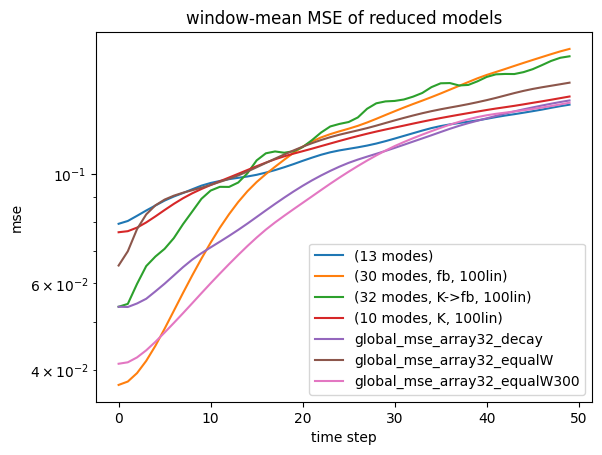

In [176]:
#lower_gmse = global_mse_mean - global_mse_std
#upper_gmse = global_mse_mean + global_mse_std
plot_evolution([global_mse_array13, global_mse_array30_new, global_mse_array32_new, global_mse_array10_new, global_mse_array32_decay, global_mse_array32_equalW, global_mse_array32_equalW300], ["(13 modes)", "(30 modes, fb, 100lin)", "(32 modes, K->fb, 100lin)", "(10 modes, K, 100lin)", "global_mse_array32_decay", "global_mse_array32_equalW", "global_mse_array32_equalW300"], "window-mean MSE of reduced models", "time step", "mse")

In [ ]:
plot_evolution([global_mse128_mean, global_mse27_mean, global_mse9_mean, global_mse_array32_equalW], ["(128 modes, full)","(27 modes)", "(9 modes)",], "window-mean MSE of reduced models", "time step", "mse")

In [ ]:
timestep_mse = np.mean(mse_array, 1)

In [ ]:
plot_evolution([timestep_mse], ["timestep mse"], "MSE(predicted, real) over timesteps", "time step", "error")

In [ ]:
x_t_stable = stable_predicted_trajectory[300]
vx = x_t_stable[0,:]
vz = x_t_stable[1,:]

plot_vx_vz(vx, vz, norm_x, norm_z)

In [ ]:
animate_trajectory(stable_predicted_trajectory, "model_new_27normalized_modes_1000", norm_x, norm_z)

In [190]:
def filter_pos_imag(values, vectors, energies):
    mode_mask = values.imag >= 0
    mode_vectors = vectors[:, mode_mask]
    mode_values = values[mode_mask]
    mode_energies = energies[mode_mask]
    return mode_values, mode_vectors, mode_energies

def calculate_eigenmode_structures(eigenvectors, model, device = "cpu"):
    modes = []
    with torch.no_grad():
        for vec in eigenvectors.T:
            modes.append(model.decoder(torch.FloatTensor(vec.real).unsqueeze(0).to(device)).squeeze(0).cpu().numpy())
    return modes

In [191]:
mode_values, mode_vectors, mode_energies = filter_pos_imag(stable_values, stable_vectors, stable_energies)

(0.9228220582008362+0.3840853273868561j) 	 0.999560948524849
188.99581909179688


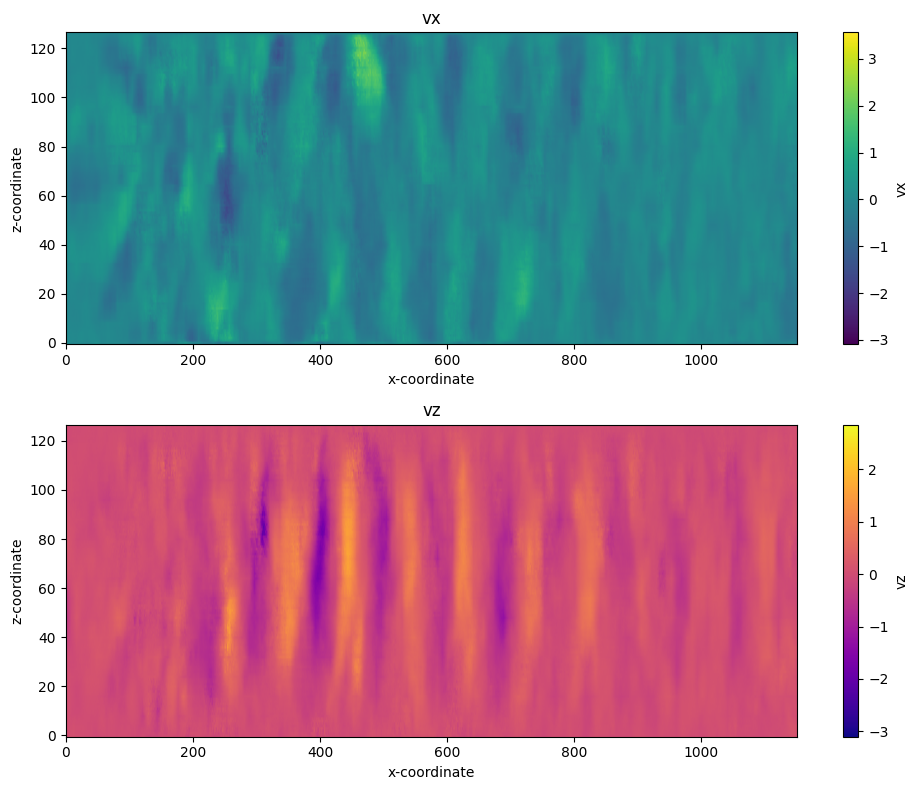

(0.9342779517173767+0.35939744114875793j) 	 1.0010203852916741
160.78402709960938


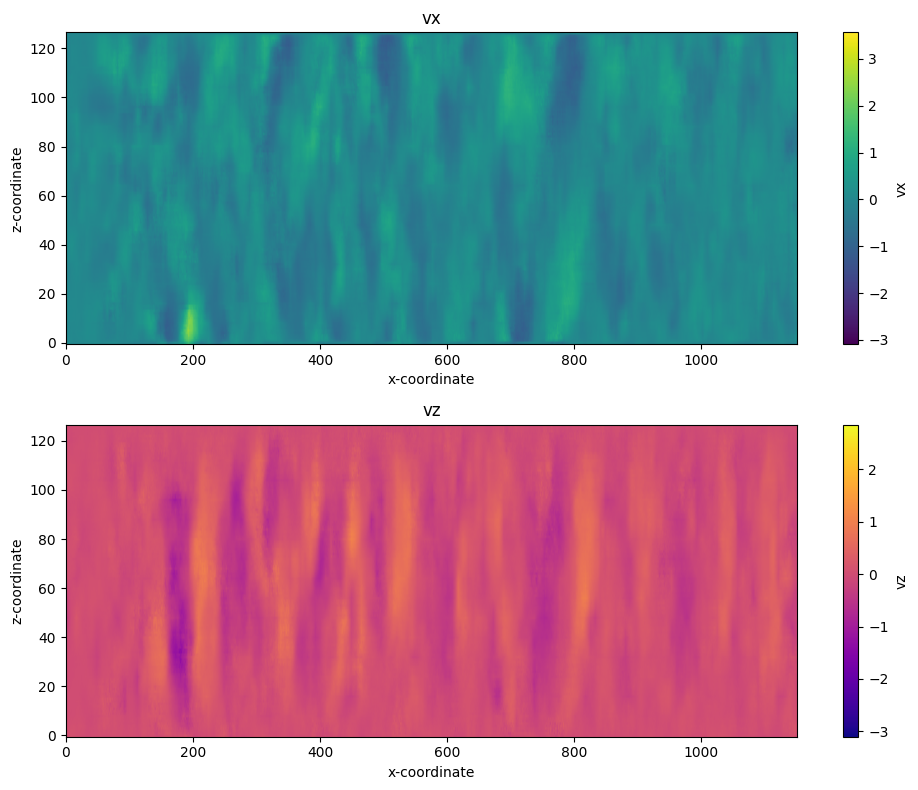

(0.9466919302940369+0.32012709975242615j) 	 0.9993532763141119
217.8200225830078


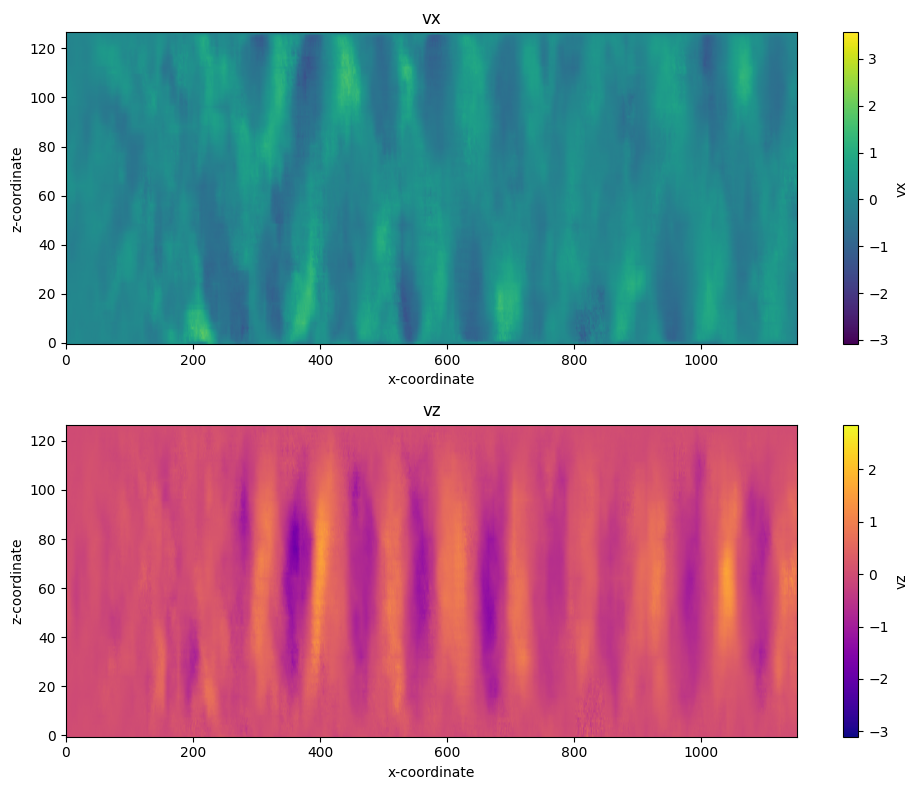

(0.9555312991142273+0.2875875234603882j) 	 0.9978710574202472
214.38868713378906


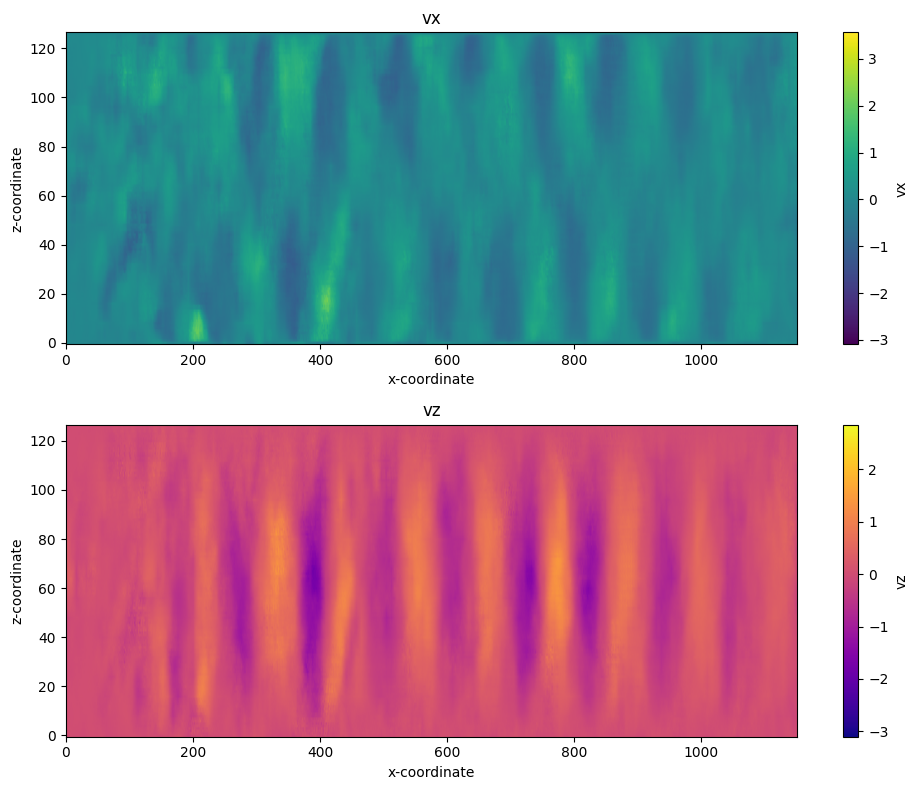

(0.9698984026908875+0.2509751319885254j) 	 1.0018440140156513
190.48886108398438


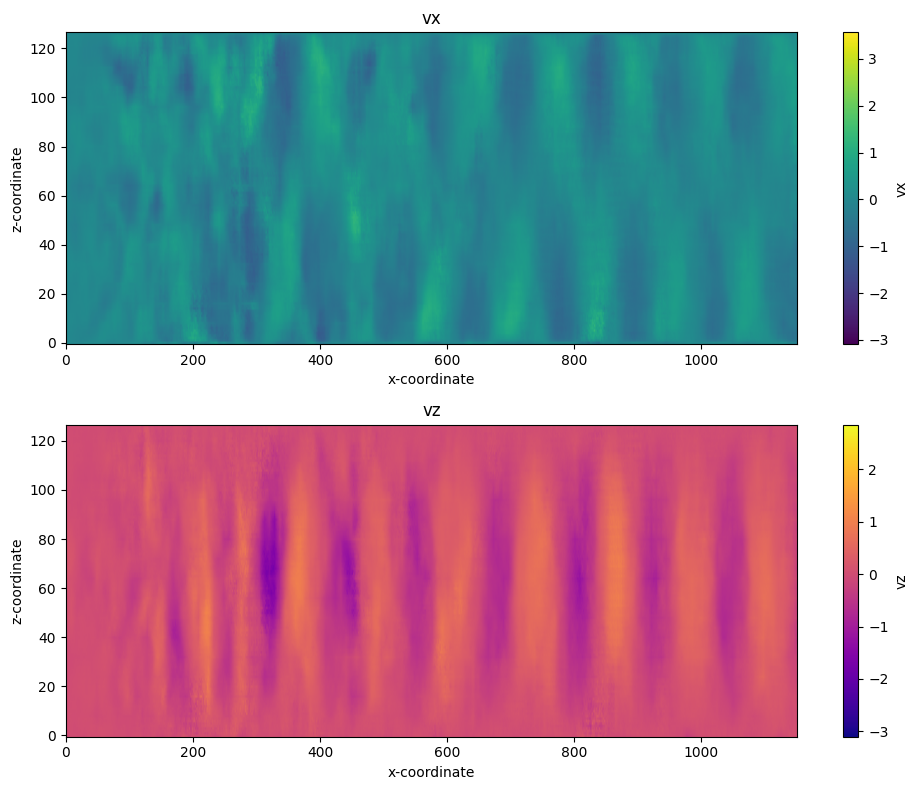

(0.9678179025650024+0.23882393538951874j) 	 0.99684921860844
228.96469116210938


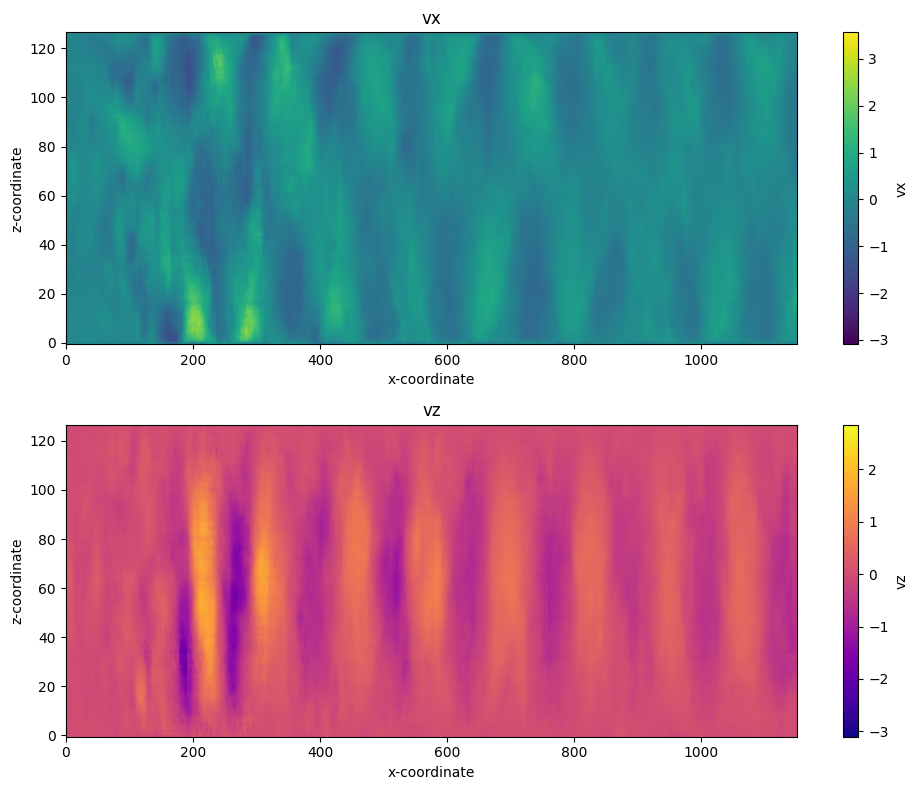

(0.9782719016075134+0.210439994931221j) 	 1.0006502410639957
245.5469512939453


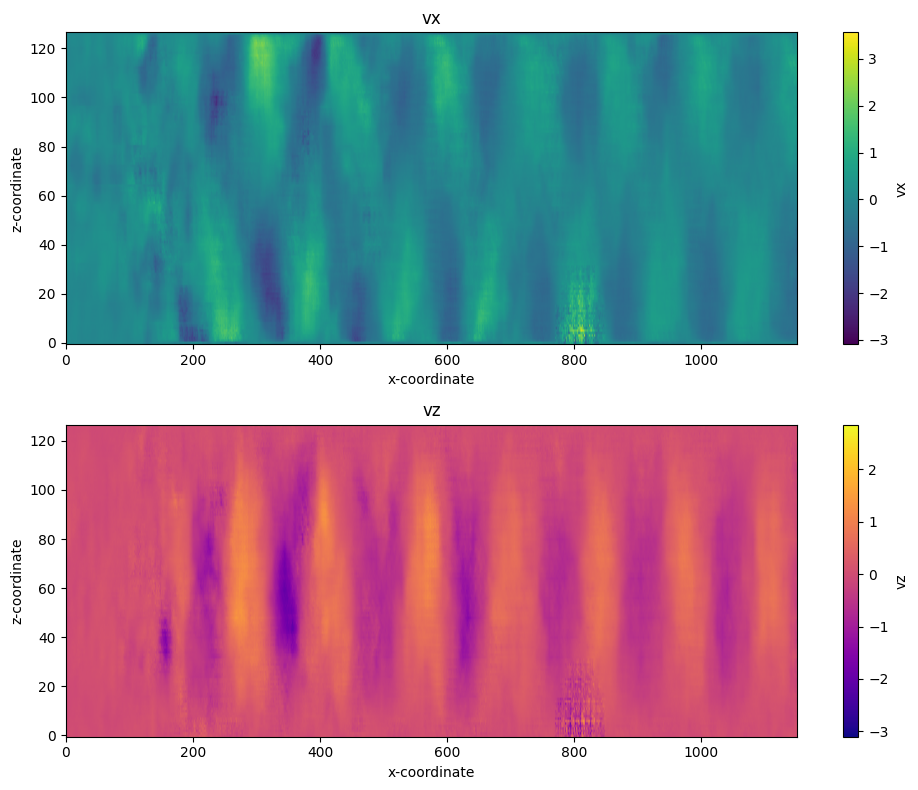

(0.981408953666687+0.19065015017986298j) 	 0.9997554771546618
231.31912231445312


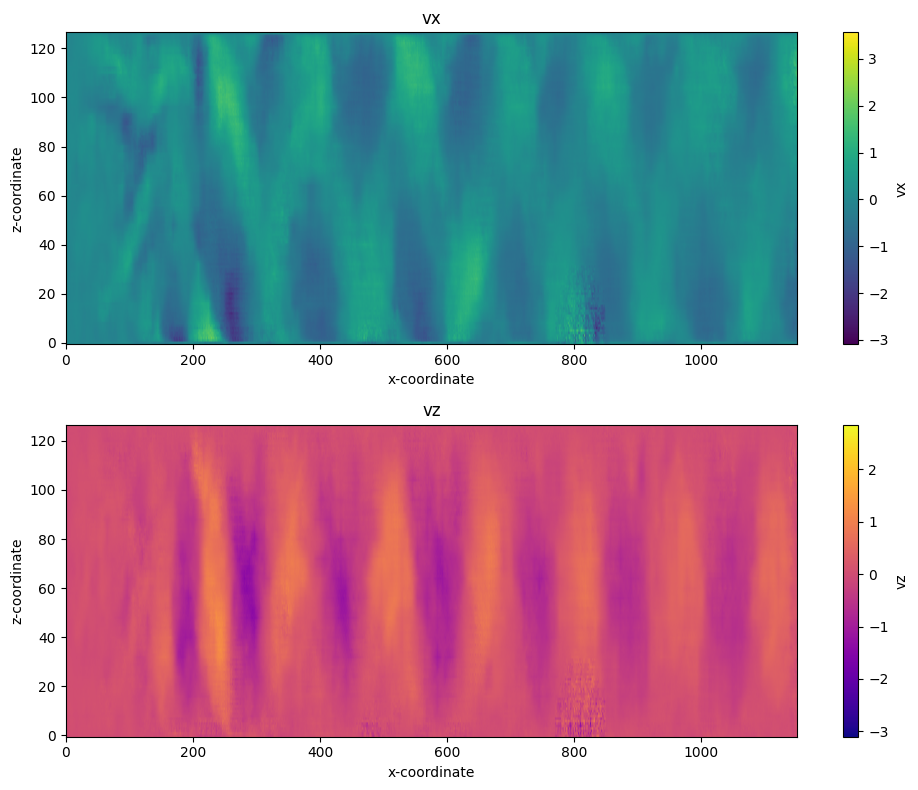

(0.9836154580116272+0.16424228250980377j) 	 0.9972336218777691
234.84080505371094


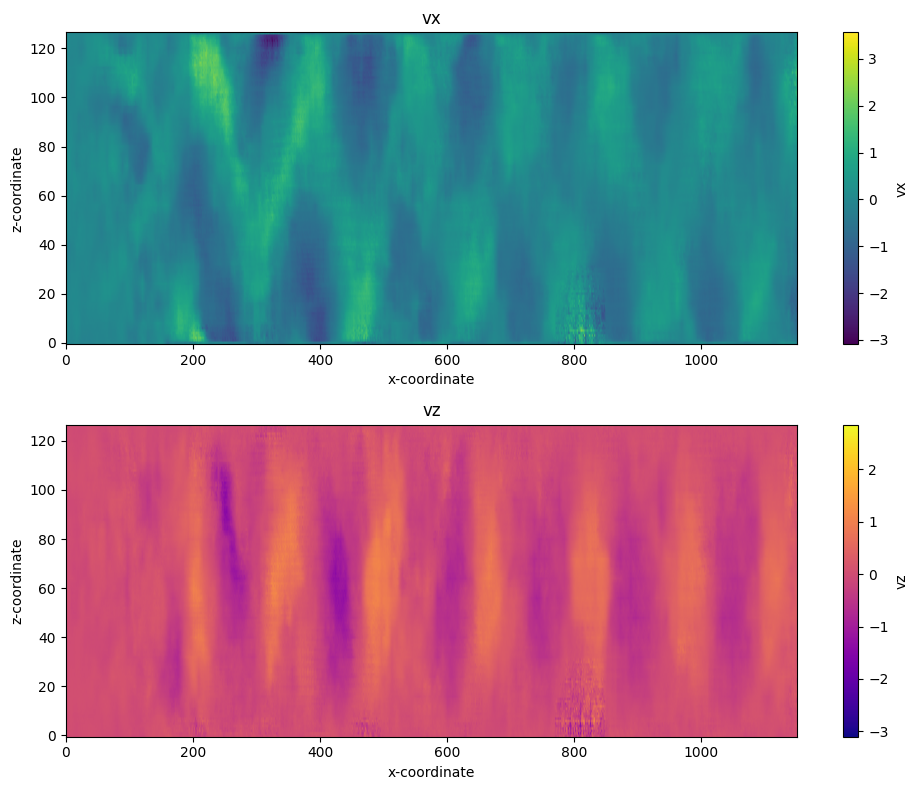

(0.985022783279419+0.16953875124454498j) 	 0.9995065141123858
222.37109375


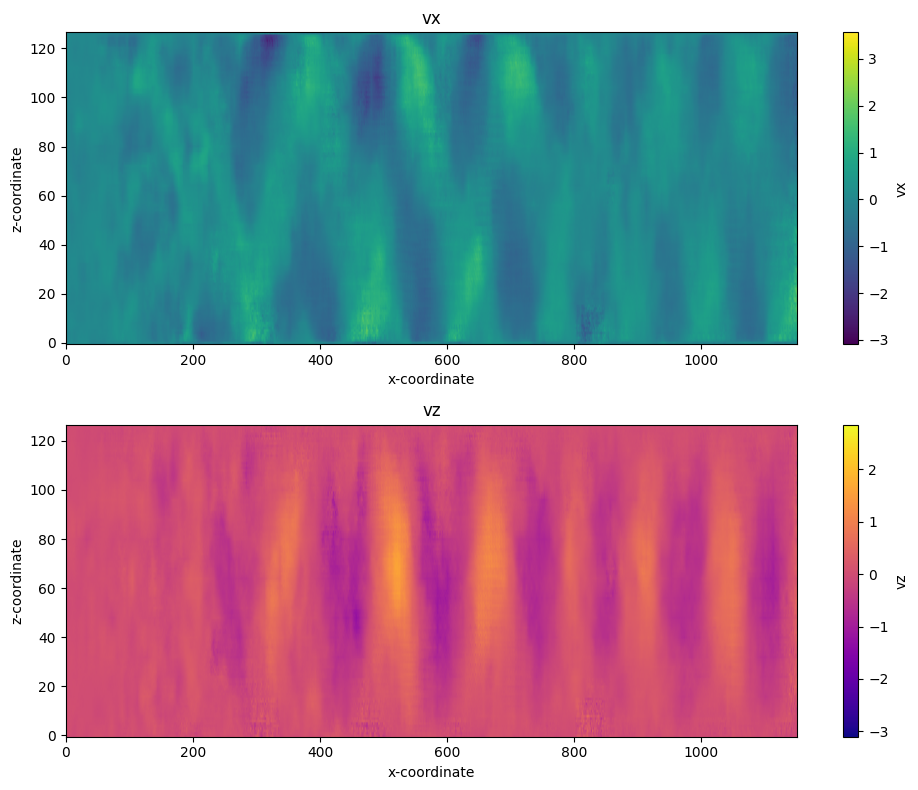

(0.9914894104003906+0.12695632874965668j) 	 0.9995844938501723
225.8408660888672


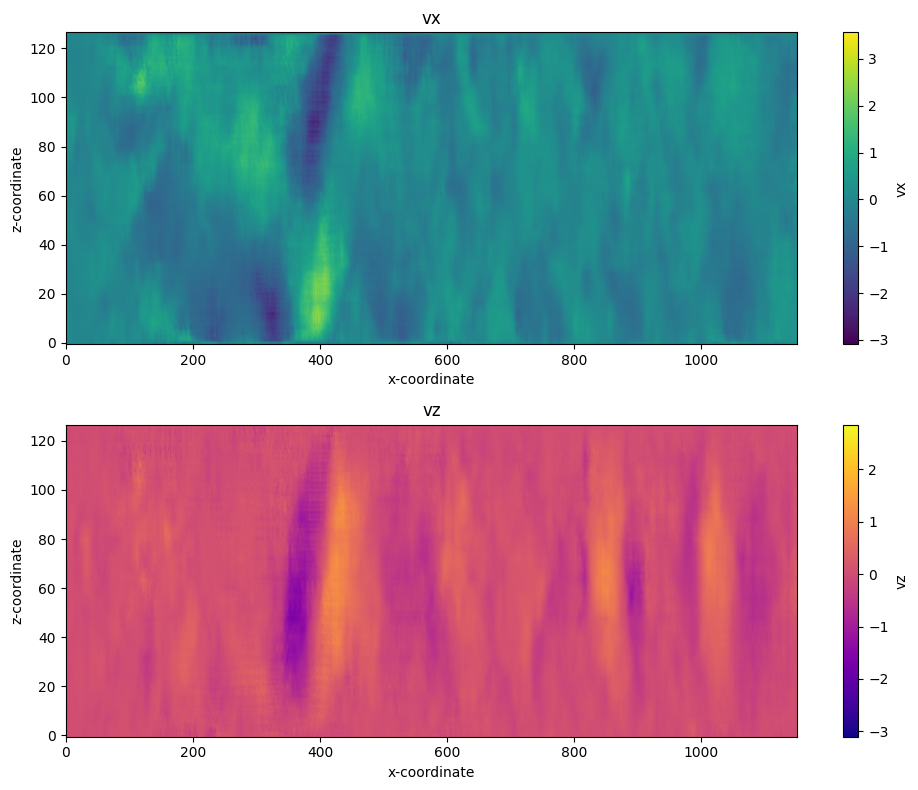

(0.9937085509300232+0.11025533825159073j) 	 0.9998064431700864
182.66036987304688


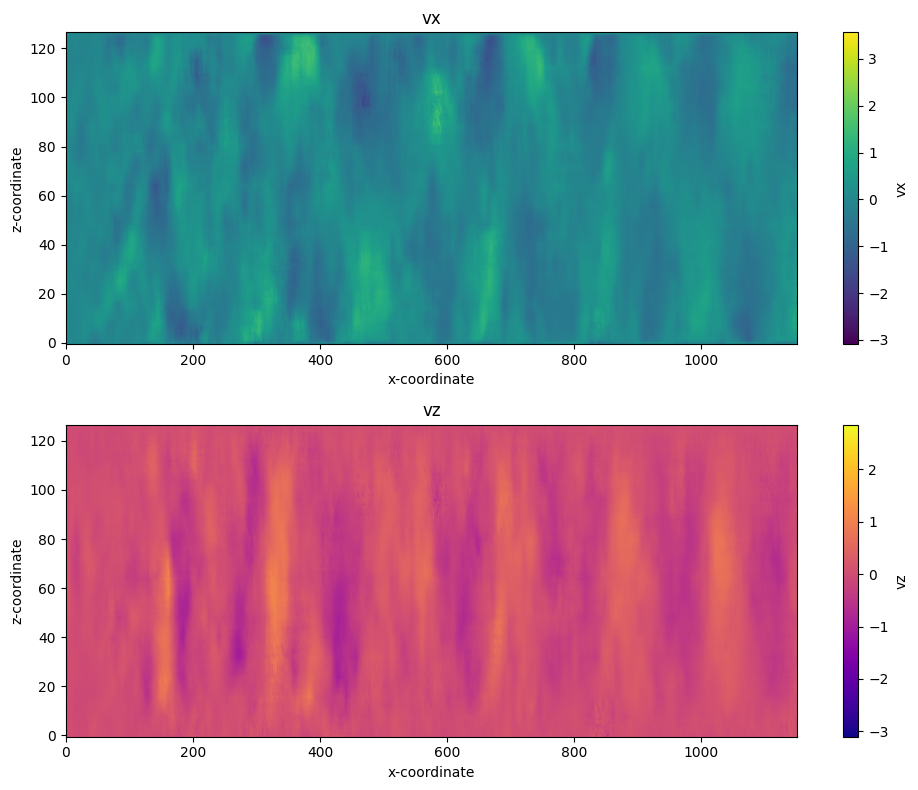

(0.9936981797218323+0.07543466985225677j) 	 0.9965573048240637
234.79359436035156


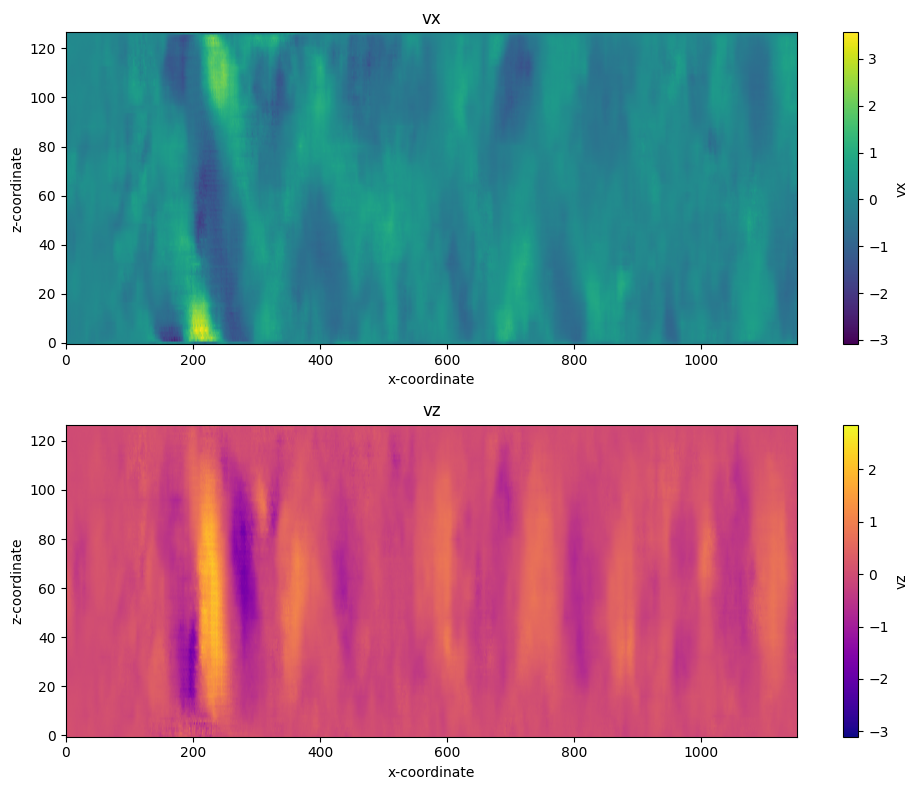

(0.9997408986091614+0.04904841631650925j) 	 1.0009433607827225
260.79364013671875


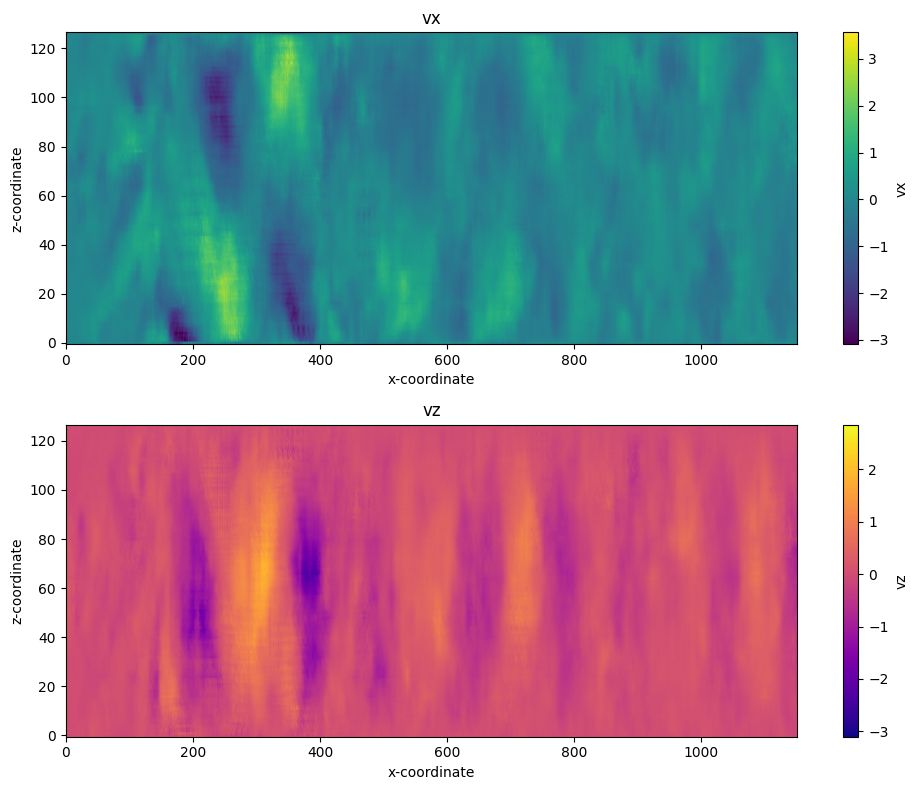

(0.997896134853363+0.027871666476130486j) 	 0.998285292763265
184.8439483642578


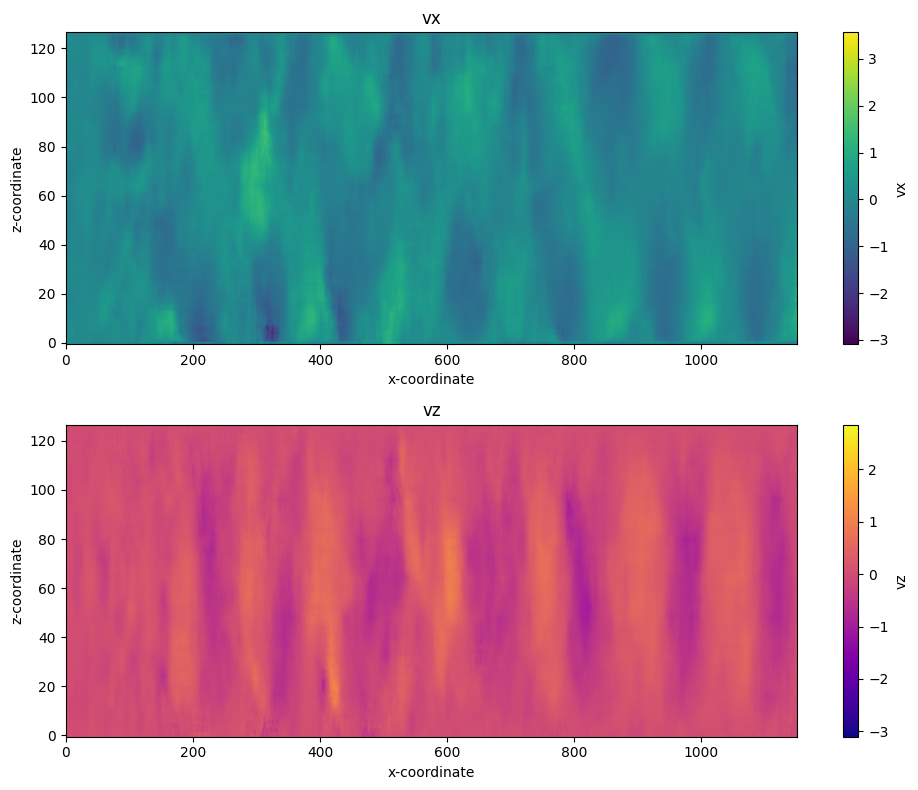

(0.9995209574699402+0.013164883479475975j) 	 0.9996076523209766
185.1006317138672


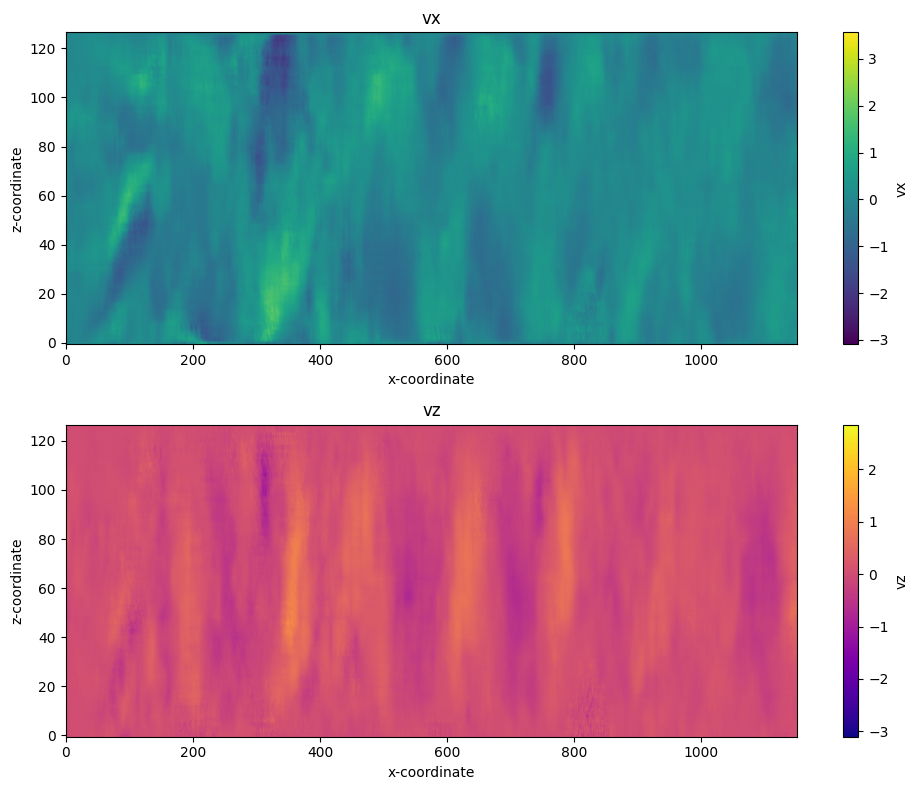

In [192]:
stable_structures = calculate_eigenmode_structures(mode_vectors, kae_model)
for i, structure in enumerate(stable_structures):
    print(mode_values[i].item(),"\t", np.abs(mode_values[i].item()))
    print(mode_energies[i])
    vx = structure[0,:]
    vz = structure[1,:]
    plot_vx_vz(vx, vz, norm_x, norm_z)

In [ ]:
x0, _ = dataset[0]
x0 = x0.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    z0 = kae_model.encoder(x0)

z0 = z0.squeeze(0).to(torch.complex64)
# Compute coefficients in modal basis
c0 = torch.linalg.pinv(V_nondecay) @ z0

def koopman_evolve(t):
    Lambda_t_diag = torch.diag(torch.exp(torch.log(E_nondecay_normalized) * t))
    z_t_complex = V_nondecay @ Lambda_t_diag @ c0
    return z_t_complex.real.unsqueeze(0)

def reconstruct_state(t):
    z_t_predicted = koopman_evolve(t)
    x_t_reconstructed = kae_model.decoder(z_t_predicted)
    return x_t_reconstructed.squeeze(0)

AttributeError: 'numpy.ndarray' object has no attribute 'unsqueeze'

In [ ]:
steady_state_prediction = []
with torch.no_grad():
    for t in range(1500):
        reconstructed_x_t = reconstruct_state(t).cpu().numpy()
        steady_state_prediction.append(reconstructed_x_t)

In [ ]:
x_t_stable = steady_state_prediction[1000]
vx = x_t_stable[0,:]
vz = x_t_stable[1,:]

plot_vx_vz(vx, vz)

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter

#n_timesteps = len(steady_state_prediction)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Initialize first frame
vx = data[0, :, :, 0]
vz = data[0, :, :, 1]

im_vx = axes[0].imshow(vx.T, origin='lower', aspect='auto', cmap='viridis', norm=norm_x)
axes[0].set_title("vx at time frame 0")
axes[0].set_xlabel("x-coordinate")
axes[0].set_ylabel("z-coordinate")
fig.colorbar(im_vx, ax=axes[0], label="vx")

im_vz = axes[1].imshow(vz.T, origin='lower', aspect='auto', cmap='plasma', norm=norm_z)
axes[1].set_title("vz")
axes[1].set_xlabel("x-coordinate")
axes[1].set_ylabel("z-coordinate")
fig.colorbar(im_vz, ax=axes[1], label="vz")

plt.tight_layout()

def update(frame):
    print(frame)
    vx = data[frame, :, :, 0]
    vz = data[frame, :, :, 1]
    
    im_vx.set_data(vx.T)
    im_vz.set_data(vz.T)
    
    axes[0].set_title(f"vx at time frame {frame}")
    #axes[1].set_title(f"vz")
    
    return [im_vx, im_vz]

ani = FuncAnimation(fig, update,
                    frames=range(data.shape[0]),
                    interval=30,
                    blit=False)

# Save as GIF (requires Pillow)
writer = PillowWriter(fps=20)
ani.save("velocity_field_true_full.gif", writer=writer)

plt.show()